In [3]:
from __future__ import print_function, division
import os
import torch
import pandas as pd
from skimage import io, transform
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils, datasets, models

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"]="2"

In [4]:
#from lib import RadioUNet_modules3, RadioUNet_loaders2
from lib import loaders, modules

## Dataset Loader, RadioUNetc threshold=0.2

In [5]:
from torch.utils.data import Subset # 新加的这一行：引入 PyTorch 的裁剪工具

Radio_train = loaders.RadioUNet_c(phase="train")
Radio_val = loaders.RadioUNet_c(phase="val")
Radio_test = loaders.RadioUNet_c(phase="test")

Radio_train = Subset(Radio_train, range(50))
Radio_val = Subset(Radio_val, range(10))
Radio_test = Subset(Radio_test, range(10))
# ===============================================

image_datasets = {
    'train': Radio_train, 'val': Radio_val
}

batch_size = 2 # 每次喂 2 张图，对轻薄本非常友好

from torch.utils.data import DataLoader # 确保 DataLoader 被正确引入
dataloaders = {
    'train': DataLoader(Radio_train, batch_size=batch_size, shuffle=True),
    'val': DataLoader(Radio_val, batch_size=batch_size, shuffle=True)
}

## Test Sample Image

In [ ]:
i=10
image_build_ant, image_gain = Radio_train[i]
plt.imshow(image_gain[0])

In [ ]:
plt.imshow(image_build_ant[0])

## Load Model and Summary

In [6]:
# from torchsummary import summary # 删掉：我们不需要看详细体检报告了，直接干活

torch.set_default_dtype(torch.float32)
# torch.set_default_tensor_type('torch.cuda.FloatTensor') # 删掉：不能强制电脑使用显卡
# torch.backends.cudnn.enabled # 删掉：显卡加速功能跳过

# ⭐ 组装模型的核心代码保留
model = modules.RadioWNet(phase="firstU") 

# model.cuda() # 删掉：不去显卡里跑
model.to("cpu") # 新增：智能分配，根据我们前面探测到的情况，让它踏踏实实留在 CPU 里运行

# summary(model, input_size=(2, 256,256)) # 删掉
print("模型组装完毕，排雷成功，准备点火！")

模型组装完毕，排雷成功，准备点火！


## Training Loop

In [ ]:
#Adapted from https://github.com/usuyama/pytorch-unet

import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy
from collections import defaultdict
import torch.nn.functional as F
import torch.nn as nn

def calc_loss_dense(pred, target, metrics):
    criterion = nn.MSELoss()
    loss = criterion(pred, target)
    metrics['loss'] += loss.data.cpu().numpy() * target.size(0)

    return loss

def calc_loss_sparse(pred, target, samples, metrics, num_samples):
    criterion = nn.MSELoss()
    loss = criterion(samples*pred, samples*target)*(256**2)/num_samples
    metrics['loss'] += loss.data.cpu().numpy() * target.size(0)

    return loss

def print_metrics(metrics, epoch_samples, phase):
    outputs1 = []
    outputs2 = []
    for k in metrics.keys():
        outputs1.append("{}: {:4f}".format(k, metrics[k] / epoch_samples))

    print("{}: {}".format(phase, ", ".join(outputs1)))

def train_model(model, optimizer, scheduler, num_epochs=10, WNetPhase="firstU", targetType="dense", num_samples=300):
    # WNetPhase: traine first U and freez second ("firstU"), or vice verse ("secondU").
    # targetType: train against dense images ("dense") or sparse measurements ("sparse")
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 1e10

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        since = time.time()

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                scheduler.step()
                for param_group in optimizer.param_groups:
                    print("learning rate", param_group['lr'])

                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            metrics = defaultdict(float)
            epoch_samples = 0

            if targetType=="dense":
                for inputs, targets in dataloaders[phase]:
                    inputs = inputs.to(device)
                    targets = targets.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        [outputs1,outputs2] = model(inputs)
                        if WNetPhase=="firstU":
                            loss = calc_loss_dense(outputs1, targets, metrics)
                        else:
                            loss = calc_loss_dense(outputs2, targets, metrics)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    epoch_samples += inputs.size(0)
            elif targetType=="sparse":
                for inputs, targets, samples in dataloaders[phase]:
                    inputs = inputs.to(device)
                    targets = targets.to(device)
                    samples = samples.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        [outputs1,outputs2] = model(inputs)
                        if WNetPhase=="firstU":
                            loss = calc_loss_sparse(outputs1, targets, samples, metrics, num_samples)
                        else:
                            loss = calc_loss_sparse(outputs2, targets, samples, metrics, num_samples)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    epoch_samples += inputs.size(0)

            print_metrics(metrics, epoch_samples, phase)
            epoch_loss = metrics['loss'] / epoch_samples

            # deep copy the model
            if phase == 'val' and epoch_loss < best_loss:
                print("saving best model")
                best_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())

        time_elapsed = time.time() - since
        print('{:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))

    print('Best val loss: {:4f}'.format(best_loss))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

## Training First UNet


In [ ]:
import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)


optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=30, gamma=0.1)

model = train_model(model, optimizer_ft, exp_lr_scheduler)

## Create Directory For Saving the Model and Examples

In [ ]:
import os
try: 
    os.mkdir('RadioWNet_c_DPM_Thr2') 
except OSError as error: 
    
    print(error) 

## Save First U Model For Inference

In [ ]:
torch.save(model.state_dict(), 'RadioWNet_c_DPM_Thr2/Trained_Model_FirstU.pt')

## Load Second U Model For Inference

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = modules.RadioWNet(phase="firstU")
model.load_state_dict(torch.load('RadioWNet_c_DPM_Thr2/Trained_Model_FirstU.pt'))
model.to(device)

## Second U Module

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model =modules.RadioWNet(phase="secondU")
model.load_state_dict(torch.load('RadioWNet_c_DPM_Thr2/Trained_Model_FirstU.pt'))
model.to(device)

## Training Scond UNet

In [ ]:
import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)


optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=30, gamma=0.1)

model = train_model(model, optimizer_ft, exp_lr_scheduler, WNetPhase="secondU")

## Save Second U Model For Inference

In [ ]:
torch.save(model.state_dict(), 'RadioWNet_c_DPM_Thr2/Trained_Model_SecondU.pt')

## Load Second U Model For Inference

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = modules.RadioWNet(phase="secondU")
model.load_state_dict(torch.load('RadioWNet_c_DPM_Thr2/Trained_Model_SecondU.pt'))
model.to(device)

## Test Accuracy

In [ ]:
import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy
from collections import defaultdict
import torch.nn.functional as F
import torch.nn as nn

def calc_loss_test(pred1, pred2, target, metrics, error="MSE"):
    criterion = nn.MSELoss()
    if error=="MSE":
        loss1 = criterion(pred1, target)
        loss2 = criterion(pred2, target)
    else:
        loss1 = criterion(pred1, target)/criterion(target, 0*target)
        loss2 = criterion(pred2, target)/criterion(target, 0*target)
    metrics['loss first U'] += loss1.data.cpu().numpy() * target.size(0)
    metrics['loss second U'] += loss2.data.cpu().numpy() * target.size(0)

    return [loss1,loss2]

def print_metrics_test(metrics, epoch_samples, error):
    outputs = []
    for k in metrics.keys():
        outputs.append("{}: {:4f}".format(k, metrics[k] / epoch_samples))
    print("{}: {}".format("Test"+" "+error, ", ".join(outputs)))

def test_loss(model, error="MSE", dataset="coarse"):
    # dataset is "coarse" or "fine".
    since = time.time()
    model.eval()   # Set model to evaluate mode
    metrics = defaultdict(float)
    epoch_samples = 0
    if dataset=="coarse":
        for inputs, targets in DataLoader(Radio_test, batch_size=batch_size, shuffle=True, num_workers=1):
            inputs = inputs.to(device)
            targets = targets.to(device)
            # do not track history if only in train
            with torch.set_grad_enabled(False):
                [outputs1,outputs2] = model(inputs)
                [loss1,loss2] = calc_loss_test(outputs1, outputs2, targets, metrics, error)
                epoch_samples += inputs.size(0)
    elif dataset=="fine":  
        for inputs, targets, samples in DataLoader(Radio_test, batch_size=batch_size, shuffle=True, num_workers=1):
            inputs = inputs.to(device)
            targets = targets.to(device)
            # do not track history if only in train
            with torch.set_grad_enabled(False):
                [outputs1,outputs2] = model(inputs)
                [loss1,loss2] = calc_loss_test(outputs1, outputs2, targets, metrics, error)
                epoch_samples += inputs.size(0)
    print_metrics_test(metrics, epoch_samples, error)
    #test_loss1 = metrics['loss U'] / epoch_samples
    #test_loss2 = metrics['loss W'] / epoch_samples
    time_elapsed = time.time() - since
    print('{:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))

### MSE Accuracy on DPM

In [ ]:
test_loss(model,error="MSE")

### NMSE Accuracy on DPM

In [ ]:
test_loss(model,error="NMSE")

## Sampled IRT4 Data Loader 

In [ ]:
Radio_train = loaders.RadioUNet_c_sprseIRT4(phase="train")
Radio_val = loaders.RadioUNet_c_sprseIRT4(phase="val")
Radio_test = loaders.RadioUNet_c_sprseIRT4(phase="test")

image_datasets = {
    'train': Radio_train, 'val': Radio_val
}

batch_size = 15

dataloaders = {
    'train': DataLoader(Radio_train, batch_size=batch_size, shuffle=True, num_workers=1),
    'val': DataLoader(Radio_val, batch_size=batch_size, shuffle=True, num_workers=1)
}

## Test Zer-Shot Accuracy On IRT4

### MSE Accuracy on DPM

In [ ]:
test_loss(model,error="MSE", dataset="fine")

### NMSE Accuracy on DPM

In [ ]:
test_loss(model,error="NMSE", dataset="fine")

## Training Sampled IRT4 UNet

In [ ]:
import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)


optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=30, gamma=0.1)

model = train_model(model, optimizer_ft, exp_lr_scheduler, WNetPhase="secondU", targetType="sparse")

## Save Adaptation to IRT4 Model For Inference

In [ ]:
torch.save(model.state_dict(), 'RadioWNet_c_DPM_Thr2/Trained_Model_IRT4.pt')

## Load Adaptation to IRT4 Model For Inference

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = modules.RadioWNet(phase="secondU")
model.load_state_dict(torch.load('RadioWNet_c_DPM_Thr2/Trained_Model_IRT4.pt'))
model.to(device)

## Test Adaptation to IRT4 Accuracy On IRT4

### MSE Accuracy on IRT4

In [ ]:
test_loss(model,error="MSE", dataset="fine")

### NMSE Accuracy on IRT4

In [ ]:
test_loss(model,error="NMSE", dataset="fine")

# Save Image Examples

## Create Directory For Saving Examples

In [ ]:
import os
try: 
    os.mkdir('RadioWNet_c_DPM_Thr2/Examples') 
except OSError as error: 
    print(error) 

## Save Examples IRT4

In [ ]:
maps_inds=np.arange(0,700,1,dtype=np.int16)
#Standard determenistic "random" shuffle of the maps:
np.random.seed(42)
np.random.shuffle(maps_inds)
            
from PIL import Image
for mapp in range(1,99):
    name00=str(mapp)
    name0=str(maps_inds[600+mapp])
    Radio_test2 = loaders.RadioUNet_c_sprseIRT4(maps_inds=maps_inds, phase="custom", 
                                               ind1=600+mapp, ind2=600+mapp, num_samples=300)
    
   
    ii=0
    for inputs, target, samps in DataLoader(Radio_test2, batch_size=1, shuffle=False, num_workers=0):
        ii=ii+1
        inputs = inputs.to(device)
        target = target.to(device)
        pred1, pred = model(inputs)
        pred = (256*pred.detach().cpu().numpy()).astype(np.uint8)
        builds=inputs.detach().cpu().numpy()
        builds=builds[0][0]
        indB=builds!=0
        im=np.zeros([256,256,3])
        im[:,:,0] = (pred[0][0])
        im[:,:,1] = (pred[0][0])
        im[:,:,2] = (pred[0][0])
        im[indB,2]=100
        im = Image.fromarray(im.astype(np.uint8))

        name=str(ii)
        #file_name="buildC_carsN_simulD_DMP_samplesN/%spredict.png" %name
        file_name="RadioWNet_c_DPM_Thr2/Examples/" +name00+ "_"+name0+ "_"+ name + "IRT4_predict.png" 
        im.save(file_name)
        #file_name="%spredict.png" %name
        Gtruth = (256*target.detach().cpu().numpy() )#.astype(np.uint8)
        im=np.zeros([256,256,3])
        im[:,:,0]=Gtruth[0][0]
        im[:,:,1]=Gtruth[0][0]
        im[:,:,2]=Gtruth[0][0]
        im[indB,2]=100
        im = Image.fromarray(im.astype(np.uint8))
        #file_name="buildC_carsN_simulD_DMP_samplesN/%starget.png" %name
        file_name="RadioWNet_c_DPM_Thr2/Examples/" +name00+ "_"+name0+ "_"+ name + "IRT4_target.png"
        #file_name="%starget.png" %name
        im.save(file_name)

## Save Image Examples for DPM Data

### Load DPM Model For Inference

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = modules.RadioWNet(phase="secondU")
model.load_state_dict(torch.load('RadioWNet_c_DPM_Thr2/Trained_Model_SecondU.pt'))
model.to(device)

## Save Examples DPM

In [ ]:
maps_inds=np.arange(0,700,1,dtype=np.int16)
#Standard determenistic "random" shuffle of the maps:
np.random.seed(42)
np.random.shuffle(maps_inds)
            
from PIL import Image
for mapp in range(1,99):
    name00=str(mapp)
    name0=str(maps_inds[600+mapp])
    Radio_test2 = loaders.RadioUNet_c(maps_inds=maps_inds, phase="custom", 
                                               ind1=600+mapp, ind2=600+mapp)
    
   
    ii=0
    for inputs, target in DataLoader(Radio_test2, batch_size=1, shuffle=False, num_workers=0):
        ii=ii+1
        if ii>2:
            break
        inputs = inputs.to(device)
        target = target.to(device)
        pred1, pred = model(inputs)
        pred = (256*pred.detach().cpu().numpy()).astype(np.uint8)
        builds=inputs.detach().cpu().numpy()
        builds=builds[0][0]
        indB=builds!=0
        im=np.zeros([256,256,3])
        im[:,:,0] = (pred[0][0])
        im[:,:,1] = (pred[0][0])
        im[:,:,2] = (pred[0][0])
        im[indB,2]=100
        im = Image.fromarray(im.astype(np.uint8))

        name=str(ii)
        #file_name="buildC_carsN_simulD_DMP_samplesN/%spredict.png" %name
        file_name="RadioWNet_c_DPM_Thr2/Examples/" +name00+ "_"+name0+ "_"+ name + "DPM_predict.png" 
        im.save(file_name)
        #file_name="%spredict.png" %name
        Gtruth = (256*target.detach().cpu().numpy() )#.astype(np.uint8)
        im=np.zeros([256,256,3])
        im[:,:,0]=Gtruth[0][0]
        im[:,:,1]=Gtruth[0][0]
        im[:,:,2]=Gtruth[0][0]
        im[indB,2]=100
        im = Image.fromarray(im.astype(np.uint8))
        #file_name="buildC_carsN_simulD_DMP_samplesN/%starget.png" %name
        file_name="RadioWNet_c_DPM_Thr2/Examples/" +name00+ "_"+name0+ "_"+ name + "DPM_target.png"
        #file_name="%starget.png" %name
        im.save(file_name)

## Show examples

In [ ]:

fig, axarr = plt.subplots(2,2, figsize=(8, 8))


im=io.imread("RadioWNet_c_DPM_Thr2/Examples/17_187_1DPM_target.png")
fig.add_subplot(2, 2, 1)
plt.imshow(im)
axarr[0, 0].set_title('Target DPM')

im=io.imread("RadioWNet_c_DPM_Thr2/Examples/17_187_1DPM_predict.png")
fig.add_subplot(2, 2, 2)
plt.imshow(im)
axarr[0, 1].set_title('Predicted DPM')

im=io.imread("RadioWNet_c_DPM_Thr2/Examples/17_187_1IRT4_target.png")
fig.add_subplot(2, 2, 3)
plt.imshow(im)
axarr[1, 0].set_title('Target IRT2')

im=io.imread("RadioWNet_c_DPM_Thr2/Examples/17_187_1IRT4_predict.png")
fig.add_subplot(2, 2, 4)
plt.imshow(im)
axarr[1, 1].set_title('Predicted IRT2')

In [ ]:

fig, axarr = plt.subplots(2,2, figsize=(8, 8))


im=io.imread("RadioWNet_c_DPM_Thr2/Examples/41_508_2DPM_target.png")
fig.add_subplot(2, 2, 1)
plt.imshow(im)
axarr[0, 0].set_title('Target DPM')

im=io.imread("RadioWNet_c_DPM_Thr2/Examples/41_508_2DPM_predict.png")
fig.add_subplot(2, 2, 2)
plt.imshow(im)
axarr[0, 1].set_title('Predicted DPM')

im=io.imread("RadioWNet_c_DPM_Thr2/Examples/41_508_2IRT4_target.png")
fig.add_subplot(2, 2, 3)
plt.imshow(im)
axarr[1, 0].set_title('Target IRT2')

im=io.imread("RadioWNet_c_DPM_Thr2/Examples/41_508_2IRT4_predict.png")
fig.add_subplot(2, 2, 4)
plt.imshow(im)
axarr[1, 1].set_title('Predicted IRT2')

In [ ]:

fig, axarr = plt.subplots(2,2, figsize=(8, 8))


im=io.imread("RadioWNet_c_DPM_Thr2/Examples/31_476_2DPM_target.png")
fig.add_subplot(2, 2, 1)
plt.imshow(im)
axarr[0, 0].set_title('Target DPM')

im=io.imread("RadioWNet_c_DPM_Thr2/Examples/31_476_2DPM_predict.png")
fig.add_subplot(2, 2, 2)
plt.imshow(im)
axarr[0, 1].set_title('Predicted DPM')

im=io.imread("RadioWNet_c_DPM_Thr2/Examples/31_476_2IRT4_target.png")
fig.add_subplot(2, 2, 3)
plt.imshow(im)
axarr[1, 0].set_title('Target IRT2')

im=io.imread("RadioWNet_c_DPM_Thr2/Examples/31_476_2IRT4_predict.png")
fig.add_subplot(2, 2, 4)
plt.imshow(im)
axarr[1, 1].set_title('Predicted IRT2')

In [ ]:
# 将模型权重保存为文件，起名叫 'my_first_radio_model.pth'
torch.save(model.state_dict(), 'my_first_radio_model.pth')
print("抢救成功！模型已安全写入硬盘。")



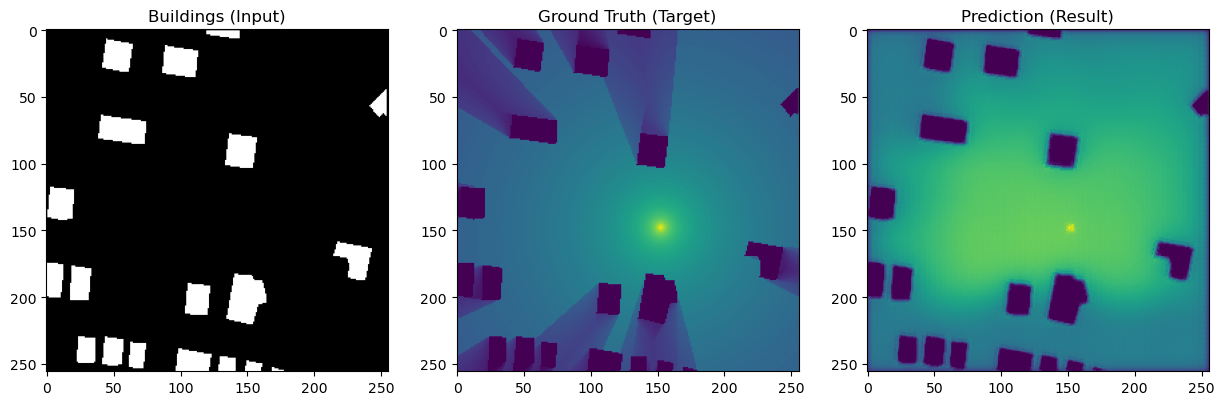

In [7]:
import torch
import matplotlib.pyplot as plt

# 1. 唤醒模型，把保存在硬盘的记忆装回脑子里 (加上 map_location 确保它在 CPU 上安全加载)
model.load_state_dict(torch.load('my_first_radio_model.pth', map_location='cpu'))
model.to("cpu")
model.eval() # 切换到“考试/推断”模式，告诉它不用再学习了，准备答题！

# 2. 从刚才加载的数据集里选一张图（比如第 5 张）
idx = 5 
inputs, targets = Radio_train[idx] # 获取输入（建筑物）和真实标签（信号图）

# 3. 让模型做预测
with torch.no_grad(): # 闭卷考试，不准计算梯度更新
    # 给图片增加一个批次维度，并送到 CPU
    input_tensor = inputs.unsqueeze(0).to("cpu") 
    outputs = model(input_tensor)
    
    # 提取输出结果
    if isinstance(outputs, list):
        prediction = outputs[0]
    else:
        prediction = outputs

# 4. 华丽的绘图对比环节
plt.figure(figsize=(15, 5))

# 第一张：模型看到的“考题”
plt.subplot(1, 3, 1)
plt.title("Buildings (Input)")
plt.imshow(inputs[0], cmap='gray') 

# 第二张：标准答案
plt.subplot(1, 3, 2)
plt.title("Ground Truth (Target)")
plt.imshow(targets[0], cmap='viridis') 

# 第三张：你亲手炼出的模型的“答卷”
plt.subplot(1, 3, 3)
plt.title("Prediction (Result)")
plt.imshow(prediction[0][0].cpu().numpy(), cmap='viridis') 

plt.show()